# Modeling Hypergraphs of MEDLINE Journals

## Model

* Let $G=(V,E)$ be a hypergraph, where $E$ is the collection of hyperedges.
* Let $H$ be the collection of admissible combinations of nodes, (e.g., if we only consider hyperedges of size less than 10). 
* $G$ is modeled as a collection of random variables ${X_h: h\in H}$.
* $X_h\sim Poisson(\lambda_h)$.
* The mean $\lambda_h$ depends on the (latent) features of nodes in $h$: $$\lambda_h=\sum_k\prod_{i\in h}r_i\theta_{ik},$$ where $\theta_{ik}$ is the percentage of node $i$ in block $k$  ($\sum_{k}\theta_{ik}=1$), and $r_i$ corresponds to the popularity of node $i$.
* Assume $X_h$'s are independent of each other given $\theta=(\theta_i)$ and $r=(r_i)$.
* The distribution of $G$ is given by $$p(G|\theta)=\prod_{h\in H} p(x_h|\theta)$$.
* Estimation: Use stochastic gradient descent to estimate $\theta$ and $r$
    * Let $\theta_{ij}=\theta_{ij}r_i$, so that we only need to deal with one set of variables $\theta$.

## Workbench

In [1]:
import time
import pandas as pd
import scipy.sparse as ssp
import numpy as np
from multiprocessing import Pool, cpu_count
from scipy.stats import dirichlet
from collections import Counter
from datetime import datetime
import random
from collections import defaultdict
from scipy.optimize import minimize
from itertools import zip_longest
from numba import guvectorize,vectorize
from numba import int64,float64,int32
from numba import cuda
import math
import pickle as pickle
from scipy.stats import pearsonr
from sklearn.metrics import precision_recall_curve
from functools import partial
import json
import sys
sys.path.insert(0, '/home/ymwan/Sci4Sci')  # or path to workspace root
from CSPaperGraph.scripts.specter2_embed import specter2_embed_papers

In [2]:
%matplotlib inline
import pylab as plt
import seaborn as sns

In [3]:
class Stopwatch:
    start_time=None
    def go(self,msg=''):
        if msg:
            print(msg, flush=True)
        self.start_time=time.time()
    def stop(self,msg=''):
        if msg:
            print("{}: {} seconds".format(msg,time.time()-self.start_time), flush=True)
        else:
            print("Elapsed time: {} seconds".format(time.time()-self.start_time), flush=True)
    def check(self):
        return time.time()-self.start_time

tic=Stopwatch()

## Load data

In [4]:
def load_date(filename):
    tic=Stopwatch()
    print("Loading paper dates %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    A=pickle.load(pkl_file,encoding='latin1')
    pkl_file.close()
    tic.stop()
    return A

def load_hypergraph(filename):
    tic=Stopwatch()
    print("Loading file %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    (row,col) = pickle.load(pkl_file,encoding='latin1')
    pkl_file.close()
    A=ssp.coo_matrix((np.ones(len(row),dtype=np.int8),(row,col)),shape=(max(row)+1, max(col)+1),dtype=np.int8)
    tic.stop()
    return A

In [ ]:
import pandas as pd
import pickle
import numpy as np

print("Loading data.pkl...")
df = pd.read_pickle('../Data/data.pkl', compression='gzip')  # or './Data/data.pkl'

target_roles = ['target']

print("Filtering papers with target roles and building Citation Hypergraph")

# 1. Filter: drop rows with missing date
df_filtered = df.dropna(subset=['date']).copy()

# 2. Extract year
df_filtered['year'] = pd.to_datetime(df_filtered['date']).dt.year.astype(int)

# 3. Normalize roles to list and filter by target_roles
#    (match if any target_role is a substring of any role)
def has_target_role(roles):
    if roles is None or (isinstance(roles, (list, np.ndarray)) and len(roles) == 0):
        return False
    roles_list = roles.tolist() if isinstance(roles, np.ndarray) else list(roles) if isinstance(roles, list) else [roles]
    return any(any(t in str(r) for t in target_roles) for r in roles_list)

df_filtered = df_filtered[df_filtered['roles'].apply(has_target_role)]


# 4. Extract cited_ids from key_references (handle dict, object, or scalar)
def extract_cited_ids(refs):
    if refs is None or (isinstance(refs, (list, np.ndarray)) and len(refs) == 0):
        return []
    refs_list = refs.tolist() if isinstance(refs, np.ndarray) else list(refs) if isinstance(refs, list) else [refs]
    cited = []
    for ref in refs_list:
        if isinstance(ref, dict) and 'corpus_id' in ref:
            cited.append(str(ref['corpus_id']))
        elif hasattr(ref, 'corpus_id'):
            cited.append(str(ref.corpus_id))
        else:
            cited.append(str(ref))
    return list(set(cited))

# Use specter2_embed_papers to get the embeddings
papers = [
    {'title': t or '', 'abstract': a or ''}
    for t, a in zip(df_filtered['title'], df_filtered['abstract'])
]
embeddings = specter2_embed_papers(papers, batch_size=32)
df_filtered['specter2_embed'] = list(embeddings)



Loading data.pkl...
Filtering papers with target roles and building Citation Hypergraph
Computing SPECTER 2.0 embeddings for 0 papers on cuda


0it [00:00, ?it/s]


In [ ]:
# Do a Truncated SVD dimension reduction for df_filtered['specter2_embed'] to retrieve the top 100 basis?
from sklearn.decomposition import TruncatedSVD

emb_matrix = np.array(df_filtered['specter2_embed'].tolist(), dtype=np.float32)

n_components = 100
svd = TruncatedSVD(n_components=n_components, random_state=42)
emb_reduced = svd.fit_transform(emb_matrix)

df_filtered['specter2_embed_100'] = list(emb_reduced)
basis_top100 = svd.components_  # shape (100, 768)

print(f"Explained variance ratio (top 100): {svd.explained_variance_ratio_.sum():.4f}")



In [ ]:
df_filtered['paper_id'] = df_filtered['corpus_id'].astype(str)
df_long = df_filtered.explode('cited_ids').dropna(subset=['cited_ids'])

# 6. Deduplicate (paper_id, cited_id) pairs
df_long = df_long[['paper_id', 'cited_ids', 'year']].drop_duplicates()

# 7. Assign integer IDs via factorize (preserves order)
df_long['row_id'] = pd.Categorical(df_long['paper_id']).codes
df_long['col_id'] = pd.Categorical(df_long['cited_ids']).codes

# 8. Build outputs
rows = df_long['row_id'].values
cols = df_long['col_id'].values

# paper_dates_list: one date per unique paper (by row order)
paper_dates_list = df_long.groupby('paper_id')['year'].first().reindex(
    pd.Categorical(df_long['paper_id']).categories
).values

# Optional: explicit id mappings (for compatibility)
paper_id_to_id = {pid: i for i, pid in enumerate(pd.Categorical(df_long['paper_id']).categories)}
cited_paper_to_id = {cid: i for i, cid in enumerate(pd.Categorical(df_long['cited_ids']).categories)}

if len(rows) > 0:
    print(f"Built hypergraph with {len(paper_id_to_id)} papers and {len(cited_paper_to_id)} unique cited papers.")
    # Save if needed:
    # with open('./Data/cs_journals.pkl', 'wb') as f:
    #     pickle.dump((rows, cols), f, protocol=pickle.HIGHEST_PROTOCOL)
    # with open('./Data/cs_paper_dates.pkl', 'wb') as f:
    #     pickle.dump(np.array(paper_dates_list), f, protocol=pickle.HIGHEST_PROTOCOL)
else:
    print("No valid citations found.")

In [ ]:
print(len(rows), len(cols))

140788 140788


In [ ]:
if len(rows) > 0:
    print(f"Built hypergraph with {len(paper_id_to_id)} AI/ML papers and {len(cited_paper_to_id)} unique cited papers.")
    
    with open('../Data/cs_journals.pkl', 'wb') as f:
        pickle.dump((rows, cols), f, protocol=pickle.HIGHEST_PROTOCOL)

    with open('../Data/cs_paper_dates.pkl', 'wb') as f:
        pickle.dump(np.array(paper_dates_list), f, protocol=pickle.HIGHEST_PROTOCOL)
        
    print("The filtered Citation Hypergraph is ready.")
else:
    print("No valid citations found.")


df.head()

Built hypergraph with 44990 AI/ML papers and 50653 unique cited papers.
The filtered Citation Hypergraph is ready.


,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory
0,55712766,math/9201203,1989-10-26,Convex bodies with few faces,"It is proved that if $u_1,\ldots, u_n$ are vec...","[math.MG, math.FA]",[target.author.publication_history.key_reference],None,None,None
1,121266415,math/9201206,1989-11-09,On the volume of the intersection of two $L_p^...,"This note deals with the following problem, th...","[math.FA, math.MG]",[target.author.publication_history.key_reference],None,None,None
2,18202490,hep-th/9108004,1991-08-16,Ground Ring Of Two Dimensional String Theory,String theories with two dimensional space-tim...,[hep-th],[target.author.publication_history.key_reference],None,None,None
3,17420406,hep-th/9108005,1991-08-19,Fusion Residues,We discuss when and how the Verlinde dimension...,[hep-th],[target.author.publication_history.key_reference],None,None,None
4,16404593,hep-th/9109005,1991-09-04,World Sheet and Space Time Physics in Two Dime...,We show that tree level ``resonant'' $N$ tachy...,[hep-th],[target.author.publication_history.key_reference],None,None,None


In [ ]:
G = load_hypergraph('../Data/cs_journals.pkl').tocsr()
paper_dates = load_date('../Data/cs_paper_dates.pkl')

Loading file ../Data/cs_journals.pkl from disk...
Elapsed time: 0.014907121658325195 seconds
Loading paper dates ../Data/cs_paper_dates.pkl from disk...
Elapsed time: 0.00014400482177734375 seconds


In [ ]:
print(f"Matrix G shape: {G.shape}, length of paper_dates: {len(paper_dates)}")
print(f"Number of non-zero elements (connections): {G.nnz}")
print(f"Unique dates in paper_dates: {np.unique(paper_dates)}")

Matrix G shape: (44990, 50653), length of paper_dates: 44990
Number of non-zero elements (connections): 140788
Unique dates in paper_dates: [2023 2024]


## Inference

In [ ]:
def get_nodes(e):
    global G0
    return tuple(sorted(G0[e,:].nonzero()[1]))
    
def get_hyperedges():
    # G: a edge-by-node incidence matrix
    global G0
    x=(G0.sum(axis=1).A.flatten()>1).nonzero()[0]
    if len(x)==0:
        return Counter()
    with Pool(cpu_count()-1) as pool:
        E=Counter(pool.map(get_nodes, x))
    return E

def batch_generator(iterable, batchsize, shuffle=False):
    if shuffle:
        iterable=list(iterable)
        random.shuffle(iterable)
    sentinel=object()
    return ([entry for entry in i if entry is not sentinel]
            for i in zip_longest(*([iter(iterable)]*batchsize), fillvalue=sentinel))

In [ ]:
from numba import njit
def edges2CSR(H):
    nodes=[]
    nodes_in=[0]
    for h in H:
        nodes+=list(h)
        nodes_in.append(len(nodes))
    return nodes, nodes_in

def CSR2CSC(nodes, nodes_in, N):
    M=ssp.csr_matrix((np.ones_like(nodes,dtype=np.int8), nodes, nodes_in), shape=(len(nodes_in)-1,N))
    M=M.tocsc()
    return M.indices, M.indptr            

@vectorize([float64(float64)], target='cuda')
def copy(x):
    return x

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],float64[:])],
             '(),    (N0,K),      (N),     (M),     (N1),    (M),     (E1),    (E),     (M),     (N1),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def dtheta(x,theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,dummy,res):
    K=theta.shape[1]
    i=int(x/K)
    z=x-i*K
    res[0]=0.0
    for j in edges[edges_in[i]:edges_in[i+1]]:
        dlam=1.0
        for u in nodes[nodes_in[j]:nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        p=0.0
        for k in range(K):
            prod=1.0
            for u in nodes[nodes_in[j]:nodes_in[j+1]]:
                prod*=theta[active[u],k]
            p+=prod
        p=max(p,1e-8)
        res[0]+=weights[j]*dlam/p-dlam 
            
    for j in rand_edges[rand_edges_in[i]:rand_edges_in[i+1]]:
        dlam=1.0
        for u in rand_nodes[rand_nodes_in[j]:rand_nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        res[0]-=dlam

@cuda.jit
def preupdate(theta,theta0,r,s):
    x, y = cuda.grid(2)
    if x < theta.shape[0] and y < theta.shape[1]:
        theta[x,y]-=1.0/(100+r)*(theta[x,y]-theta0[x,y])/s

@cuda.jit
def update(theta,active,D,r):
    x, y = cuda.grid(2)
    if x < D.shape[0] and y < D.shape[1]:
        theta[active[x], y] += 1.0/(100+r)*D[x,y]
        cuda.atomic.max(theta, (active[x], y), 0.001)

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (E),      (D)  ->  (D)', target='cuda')
def p_pos(i,theta,active,nodes,nodes_in,weights,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in nodes[nodes_in[i]:nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    if p<1e-15:
        res[0]=0
    else:
        res[0]=weights[i]*math.log(p) - p

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def p_neg(i,theta,active,rand_nodes,rand_nodes_in,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in rand_nodes[rand_nodes_in[i]:rand_nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    res[0]=-p

@cuda.reduce
def sum_reduce(a, b):
    return a + b

def logPG(theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in):
    res1=p_pos(range(weights.shape[0]),theta,active,nodes,nodes_in,weights,[0])
    sum1=sum_reduce(res1.ravel())
    res2=p_neg(range(rand_nodes_in.shape[0]-1),theta,active,rand_nodes,rand_nodes_in,[0])
    sum2=sum_reduce(res2.ravel())
    return (sum1+sum2)

def estimate(G, times, K=20, thetas=None, nepochs=5, subepochs=10, batchsize=1000, discontinue=1, outfile=None):
    # G: an edge-by-node incidence matrix; scipy sparse CSR matrix.
    # times: timestamp for each edge; 1D numpy array.
    # K: dimension of latent space.
    # thetas: intial values for the parameters; a list of node-by-K matrices with each matrix for a time point. If None, then the estimation starts from random matrices.
    # nepochs: number of repetitions of the whole process
    # subepochs: number of repetitions for each data point 
    # batchsize: batch size of training samples.
    # discontinue: correlation of the parameters between time points; the larger the value, the more dissimilar between time points.
    
    global G0
    
    tic.go('Estimating...')
    candidate_times=np.unique(times)
    if thetas is None:
        theta=np.random.dirichlet([0.5]*K,size=G.shape[1])
        thetas=[cuda.to_device(theta)]
    else:
        if K!=thetas[0].shape[1]:
            raise("K and the dimension of initial condition don't match!")
        thetas=[thetas[0]]+thetas
        thetas=[cuda.to_device(theta) for theta in thetas]
    
    # parameters for CUDA
    threadsperblock = (32,min(32,K))
    blockspergrid_x = math.ceil(thetas[0].shape[0] / threadsperblock[0])
    blockspergrid_y = math.ceil(K / threadsperblock[1])
    blockspergrid0 = (blockspergrid_x, blockspergrid_y)
    
    likelihoods=[]
    for epoch in range(nepochs):
        time_index=1
        for t in candidate_times:
            if len(thetas)==time_index:
                thetas.append(copy(thetas[-1]))
            G0=G[(times==t).nonzero()[0],:]
            active_nodes=G0.sum(axis=0).A.ravel().nonzero()[0]
            G0=G0[:,active_nodes]
            G0.data=np.ones_like(G0.data)
            E0=get_hyperedges()
            N=len(active_nodes)
            V=range(N)
            active_nodes=cuda.to_device(active_nodes)
            
            blockspergrid_x = math.ceil(N / threadsperblock[0])
            blockspergrid = (blockspergrid_x, blockspergrid_y)
                     
            if outfile:
                outfile.write("Epoch {} | Time: {} | Nodes: {} | Edges: {} | ".format(epoch,t,N,len(E0)))
                outfile.flush()
            
            for subepoch in range(subepochs):
                for batch in batch_generator(E0.items(),batchsize):
                    samples,weights=zip(*batch)
                    nodes,nodes_in=edges2CSR(samples)
                    edges,edges_in=CSR2CSC(nodes, nodes_in, N)  
                    nodes=cuda.to_device(np.array(nodes, dtype=np.int32))
                    nodes_in=cuda.to_device(np.array(nodes_in, dtype=np.int32))
                    weights=cuda.to_device(np.array(weights, dtype=np.int32))
                    edges=cuda.to_device(np.array(edges, dtype=np.int32))
                    edges_in=cuda.to_device(np.array(edges_in, dtype=np.int32))
                    E_neg=[]
                    for h in samples:
                        while True:
                            e=tuple(sorted(random.sample(V,len(h))))
                            if e not in E0:
                                E_neg.append(e)
                                break
                    rand_nodes, rand_nodes_in = edges2CSR(E_neg)
                    rand_edges, rand_edges_in = CSR2CSC(rand_nodes, rand_nodes_in, N)
                    rand_nodes=cuda.to_device(np.array(rand_nodes, dtype=np.int32))
                    rand_nodes_in=cuda.to_device(np.array(rand_nodes_in, dtype=np.int32))
                    rand_edges=cuda.to_device(np.array(rand_edges, dtype=np.int32))
                    rand_edges_in=cuda.to_device(np.array(rand_edges_in, dtype=np.int32))
                    preupdate[blockspergrid0, threadsperblock](thetas[time_index],thetas[time_index-1],(epoch+1)*(subepoch+1),discontinue)
                    D=dtheta(range(N*K),thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,[0])
                    D=D.reshape(N,K)      
                    update[blockspergrid, threadsperblock](thetas[time_index],active_nodes,D,(epoch+1)*(subepoch+1))        
                    l=logPG(thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in)
                    likelihoods.append(l/len(samples))
            if outfile:
                outfile.write('log-lik: {:.2f} | Elapsed {:.2f} s\n'.format(likelihoods[-1], tic.check()))
                outfile.flush()
            time_index+=1
        thetas[0]=thetas[1]
    tic.stop()
    return (thetas[1:], likelihoods)

In [ ]:
print("{}, # nodes: {} | # edges: {} | average degree: {} | average edge size: {}".format(datetime.now(),G.shape[1],G.shape[0],G.sum(axis=0).mean(),G.sum(axis=1).mean()))

2026-02-21 13:54:34.378299, # nodes: 2781 | # edges: 778 | average degree: 5.845019777058612 | average edge size: 20.89331619537275


In [ ]:
K = 20 # dimension of hidden space

In [ ]:
with open("output_medline_journal.txt", 'w') as logfile:
    thetas,likelihoods=estimate(G,paper_dates,K,discontinue=1.0,nepochs=5,batchsize=2000,outfile=logfile)

Estimating...


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 73 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 87 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 73 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 87 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packag

Elapsed time: 3.6546027660369873 seconds


In [ ]:
thetas=[theta.copy_to_host() for theta in thetas]

In [ ]:
with open('./Fitted_Model/block_model_medline_journal.pkl','wb') as outfile2:
    pickle.dump([thetas,likelihoods,np.unique(paper_dates)],outfile2)

## Evaluation

In [ ]:
with open('./Fitted_Model/block_model_medline_journal.pkl','rb') as infile:
    thetas,likelihoods,times=pickle.load(infile)

In [ ]:
from evaluate import evaluate

In [ ]:
res = evaluate(G, paper_dates, thetas)

Evaluating time 2020...


In [ ]:
res.head()

,time,num_nodes,num_edges,mean_edge_size,max_edge_size,mean_degree,auc,auc_std,repeated_edges
0,2020,2781,778,20.893316,157,5.84502,0.999614,0.000823,0


In [ ]:
res.to_csv("./Results/MEDLINE_journal_evaluation.csv", index=False)

In [ ]:
res['frac_repeated']=res["repeated_edges"]/res["num_edges"]

In [ ]:
df = res.copy()

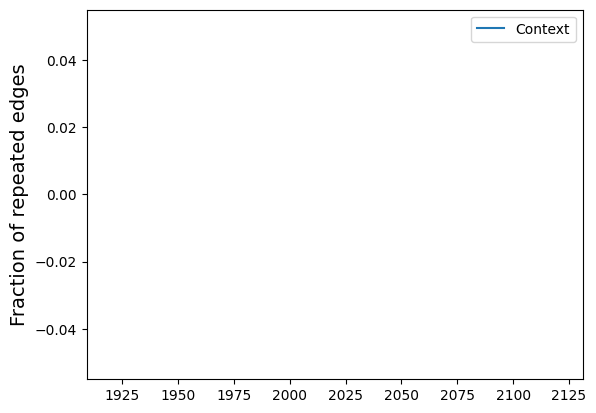

In [ ]:
plt.plot(df["time"], df["frac_repeated"], label="Context");
plt.ylabel("Fraction of repeated edges", fontsize=14);
plt.legend();